In [1]:
import os
import zipfile
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout
from google.colab import files

# Install tools for Kaggle and TFJS
!pip install opendatasets tensorflowjs -q
import opendatasets as od

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 89.1/89.1 kB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.0/53.0 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 16.1/16.1 MB 46.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 645.0/645.0 MB 2.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.7/1.7 MB 93.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 140.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 72.5/72.5 kB 8.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
bigquery-magics 0.14.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
google-cloud-bigquery 3.41.0 requires packaging>=24.2.0, but you have packaging 23.2 which is incompatible.
xarray 2025.12.0 requires packaging>=24.1, but you have packaging 2

In [2]:
import os

# URL dataset baru yang diminta
dataset_url = 'https://www.kaggle.com/datasets/techsash/waste-classification-data'

# Download dataset
od.download(dataset_url)

# Path dataset
base_dir = './waste-classification-data/DATASET/final_data'

Please provide your Kaggle credentials to download this dataset. Learn more: http://bit.ly/kaggle-creds
Your Kaggle username: Aioloo
Your Kaggle Key: ··········
Dataset URL: https://www.kaggle.com/datasets/techsash/waste-classification-data


100%|██████████| 427M/427M [00:04<00:00, 110MB/s]


In [3]:
import os
import shutil

# 1. Hapus folder test bawaan Kaggle (karena tidak mau dipakai)
if os.path.exists('/content/waste-classification-data/DATASET/TEST'):
    shutil.rmtree('/content/waste-classification-data/DATASET/TEST')

# 2. Rename folder train menjadi 'base_data' agar lebih jelas fungsinya
os.rename('/content/waste-classification-data/DATASET/TRAIN', '/content/waste-classification-data/DATASET/base_data')

In [4]:
!pip install split-folders -q

import splitfolders

splitfolders.ratio('/content/waste-classification-data/DATASET/base_data',
                   output='/content/waste-classification-data/DATASET/final_data',
                   seed=42,
                   ratio=(.8, .1, .1))

Copying files: 22564 files [00:03, 5689.18 files/s]


In [5]:
base_dir = './waste-classification-data/DATASET/final_data/train'

In [6]:
from PIL import Image
import os

def print_images_resolution(directory):
    unique_sizes = set()
    total_images = 0

    if not os.path.exists(directory):
        print(f"Direktori {directory} tidak ditemukan.")
        return

    for subdir in os.listdir(directory):
        subdir_path = os.path.join(directory, subdir)
        if not os.path.isdir(subdir_path): continue

        image_files = [f for f in os.listdir(subdir_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        num_images = len(image_files)
        print(f"{subdir}: {num_images} gambar")
        total_images += num_images

        for img_file in image_files[:10]: # Cek 10 gambar pertama saja untuk efisiensi
            img_path = os.path.join(subdir_path, img_file)
            try:
                with Image.open(img_path) as img:
                    unique_sizes.add(img.size)
            except:
                continue

        print(f"  Contoh resolusi: {list(unique_sizes)[:3]}")
        print("---------------")

    print(f"\nTotal Keseluruhan Gambar: {total_images}")

# Jalankan fungsi untuk mengecek folder train
print_images_resolution(base_dir)

O: 10052 gambar
  Contoh resolusi: [(340, 148), (201, 251), (225, 225)]
---------------
R: 7999 gambar
  Contoh resolusi: [(340, 148), (201, 251), (225, 225)]
---------------

Total Keseluruhan Gambar: 18051


**Augmentasi Data**

In [7]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=40,
    horizontal_flip=True,
    shear_range=0.2,
    zoom_range=0.2,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

**Splitting**

In [8]:
image_size = (150, 150)
batch_size = 32
epochs = 20
learningrate = 0.001

In [9]:
train_generator = train_datagen.flow_from_directory(
    '/content/waste-classification-data/DATASET/final_data/train',
    target_size = image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

validation_generator = val_test_datagen.flow_from_directory(
    '/content/waste-classification-data/DATASET/final_data/val',
    target_size = image_size,
    batch_size=batch_size,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    '/content/waste-classification-data/DATASET/final_data/test',
    target_size=image_size,
    batch_size = batch_size,
    class_mode='categorical'
)


Found 18051 images belonging to 2 classes.
Found 2255 images belonging to 2 classes.
Found 2258 images belonging to 2 classes.


**Callback**

In [10]:
# Membuat callback kustom untuk menghentikan pelatihan
class myCallback(tf.keras.callbacks.Callback):
    def on_epoch_end(self, epoch, logs={}):
        if(logs.get('accuracy') > 0.85 and logs.get('val_accuracy') > 0.85):
            print("\nTarget akurasi telah tercapai, menghentikan pelatihan!")
            self.model.stop_training = True

callbacks = myCallback()

**Modelling**

In [11]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization, GlobalAveragePooling2D
from tensorflow.keras.optimizers import Adam

model = Sequential([
    # Blok 1: Menangkap tekstur sampah (organik vs plastik)
    Conv2D(32, (3,3), activation='relu', input_shape=(150, 150, 3)),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Blok 2
    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    # Blok 3
    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D(2, 2),

    Flatten(),

    # Fully Connected Layer
    Dense(128, activation='relu'), # Cukup 128 karena hanya 2 kelas
    BatchNormalization(),
    Dropout(0.5),

    # Output Layer: 2 Unit untuk Organik (O) dan Recyclable (R)
    Dense(2, activation='softmax')
])

model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history = model.fit(
    train_generator,
    epochs=epochs,
    validation_data=validation_generator,
    callbacks=[callbacks]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 136s 224ms/step - accuracy: 0.7784 - loss: 0.5531 - val_accuracy: 0.8235 - val_loss: 0.3989
Epoch 2/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 118s 209ms/step - accuracy: 0.8116 - loss: 0.4573 - val_accuracy: 0.8377 - val_loss: 0.3920
Epoch 3/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 116s 205ms/step - accuracy: 0.8283 - loss: 0.4203 - val_accuracy: 0.8395 - val_loss: 0.3944
Epoch 4/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 116s 204ms/step - accuracy: 0.8402 - loss: 0.3952 - val_accuracy: 0.8519 - val_loss: 0.3429
Epoch 5/20
565/565 ━━━━━━━━━━━━━━━━━━━━ 0s 201ms/step - accuracy: 0.8520 - loss: 0.3654
Target akurasi telah tercapai, menghentikan pelatihan!
565/565 ━━━━━━━━━━━━━━━━━━━━ 116s 206ms/step - accuracy: 0.8501 - loss: 0.3662 - val_accuracy: 0.8621 - val_loss: 0.3378


In [12]:
# Evaluasi akhir menggunakan validation generator sebagai representasi test set yang berlabel
final_loss, final_accuracy = model.evaluate(test_generator)

print(f"Final Test Loss: {final_loss}")
print(f"Final Test Accuracy: {final_accuracy * 100:.2f}%")

if final_accuracy >= 0.85:
    print("Selamat! Model Anda sudah memenuhi kriteria akurasi >85%.")
else:
    print("Akurasi masih di bawah 85%. Anda mungkin perlu menambah epoch atau mencoba arsitektur yang lebih dalam.")

71/71 ━━━━━━━━━━━━━━━━━━━━ 3s 43ms/step - accuracy: 0.8592 - loss: 0.3513
Final Test Loss: 0.35125935077667236
Final Test Accuracy: 85.92%
Selamat! Model Anda sudah memenuhi kriteria akurasi >85%.


**Evaluasi dan Visualisasi**

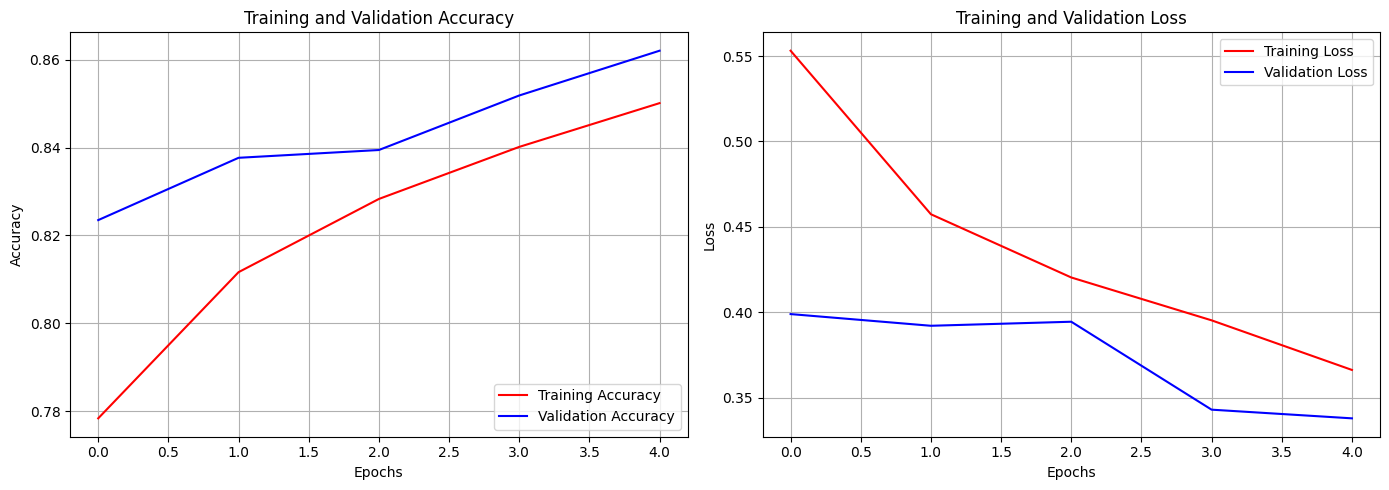

In [13]:
import matplotlib.pyplot as plt

# Mengambil data dari history
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(acc))

# Membuat canvas dengan 2 sub-plot (1 baris, 2 kolom)
plt.figure(figsize=(14, 5))

# --- GRAFIK AKURASI ---
plt.subplot(1, 2, 1)
plt.plot(epochs, acc, 'r', label='Training Accuracy')
plt.plot(epochs, val_acc, 'b', label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend(loc='lower right')
plt.grid(True)

# --- GRAFIK LOSS ---
plt.subplot(1, 2, 2)
plt.plot(epochs, loss, 'r', label='Training Loss')
plt.plot(epochs, val_loss, 'b', label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend(loc='upper right')
plt.grid(True)

plt.tight_layout()
plt.show()

**Konversi Model**

In [14]:
model.save("model.h5")

In [15]:
# Install tensorflowjs
!pip install tensorflowjs

# Convert model.h5 to model
!tensorflowjs_converter --input_format=keras model.h5 tfjs_model

2026-05-07 11:29:55.000005: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778153395.023170    8778 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778153395.030216    8778 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778153395.048063    8778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778153395.048104    8778 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778153395.048109    8778 computation_placer.cc:177] computation placer alr

In [16]:
import pathlib

# Menyimpan model dalam format SavedModel
export_dir = 'saved_model/'
model.export(export_dir)

# Convert SavedModel menjadi vegs.tflite
converter = tf.lite.TFLiteConverter.from_saved_model(export_dir)
tflite_model = converter.convert()

tflite_model_file = pathlib.Path('models.tflite')
tflite_model_file.write_bytes(tflite_model)

Saved artifact at 'saved_model/'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 150, 150, 3), dtype=tf.float32, name='keras_tensor')
Output Type:
  TensorSpec(shape=(None, 2), dtype=tf.float32, name=None)
Captures:
  132900112177808: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112178576: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112180688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112178384: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112178192: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112179728: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112180880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112181264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112182224: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112182608: TensorSpec(shape=(), dtype=tf.resource, name=None)
  132900112180496: T

21616696

**Inference (Optional)**

Saving istockphoto-629616876-612x612.jpg to istockphoto-629616876-612x612.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 949ms/step
istockphoto-629616876-612x612.jpg
[[1. 0.]]


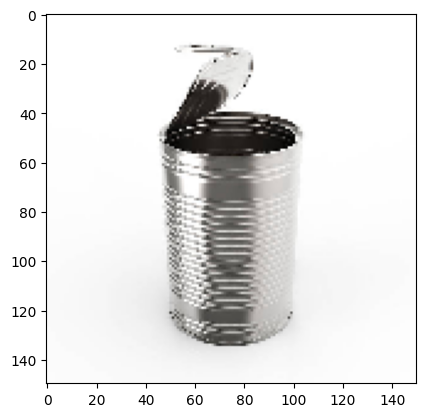

In [17]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(150, 150))
    imgplot = plt.imshow(img)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)

    print(fn)
    print(classes)

Saving sampah-makanan-organik-ember-shot-di-atas.jpg to sampah-makanan-organik-ember-shot-di-atas.jpg
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
sampah-makanan-organik-ember-shot-di-atas.jpg
[[1. 0.]]


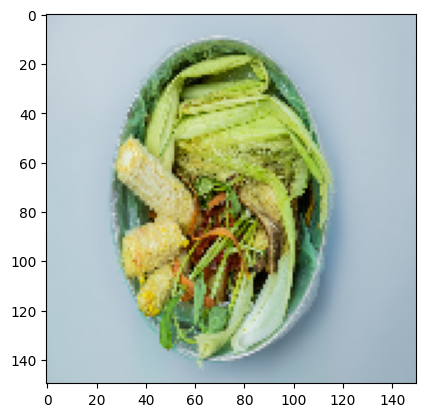

In [18]:
from google.colab import files
from tensorflow.keras.preprocessing import image

uploaded = files.upload()

for fn in uploaded.keys():
    path = fn
    img = image.load_img(path, target_size=(150, 150))
    imgplot = plt.imshow(img)
    x = image.img_to_array(img)
    x = np.expand_dims(x, axis=0)

    images = np.vstack([x])
    classes = model.predict(images, batch_size=10)

    print(fn)
    print(classes)

In [19]:
pip freeze requirements.txt

absl-py==1.4.0
accelerate==1.13.0
access==1.1.10.post3
affine==2.4.0
aiofiles==24.1.0
aiohappyeyeballs==2.6.1
aiohttp==3.13.5
aiosignal==1.4.0
aiosqlite==0.22.1
alabaster==1.0.0
albucore==0.0.24
albumentations==2.0.8
ale-py==0.11.2
alembic==1.18.4
altair==5.5.0
annotated-doc==0.0.4
annotated-types==0.7.0
antlr4-python3-runtime==4.9.3
anyio==4.13.0
anywidget==0.9.21
apsw==3.53.0.0
apswutils==0.1.2
argon2-cffi==25.1.0
argon2-cffi-bindings==25.1.0
array_record==0.8.3
arrow==1.4.0
arviz==0.22.0
astropy==7.2.0
astropy-iers-data==0.2026.4.20.0.58.15
astunparse==1.6.3
atpublic==5.1
attrs==26.1.0
audioread==3.1.0
Authlib==1.6.11
autograd==1.8.0
babel==2.18.0
backcall==0.2.0
beartype==0.22.9
beautifulsoup4==4.13.5
betterproto==2.0.0b6
bigframes==2.39.0
bigquery-magics==0.14.0
bleach==6.3.0
blinker==1.9.0
blis==1.3.3
blobfile==3.2.0
blosc2==4.1.2
bokeh==3.8.2
Bottleneck==1.4.2
bqplot==0.12.45
branca==0.8.2
brotli==1.2.0
CacheControl==0.14.4
cachetools==6.2.6
catalogue==2.0.10
certifi==2026.4.22


In [20]:
!zip -r tfjs_model.zip /content/tfjs_model/

  adding: content/tfjs_model/ (stored 0%)
  adding: content/tfjs_model/group1-shard5of6.bin (deflated 7%)
  adding: content/tfjs_model/group1-shard6of6.bin (deflated 7%)
  adding: content/tfjs_model/group1-shard3of6.bin (deflated 7%)
  adding: content/tfjs_model/group1-shard1of6.bin (deflated 7%)
  adding: content/tfjs_model/group1-shard4of6.bin (deflated 7%)
  adding: content/tfjs_model/model.json (deflated 89%)
  adding: content/tfjs_model/group1-shard2of6.bin (deflated 7%)


In [21]:
!zip -r saved_model.zip /content/saved_model/

  adding: content/saved_model/ (stored 0%)
  adding: content/saved_model/saved_model.pb (deflated 87%)
  adding: content/saved_model/fingerprint.pb (stored 0%)
  adding: content/saved_model/assets/ (stored 0%)
  adding: content/saved_model/variables/ (stored 0%)
  adding: content/saved_model/variables/variables.index (deflated 71%)
  adding: content/saved_model/variables/variables.data-00000-of-00001 (deflated 7%)
